In [20]:
# Imports
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import xml.etree.ElementTree as ET

print("All imports successful")

All imports successful


In [21]:
# Metadata parsing functions

def parse_filename(filepath):
    """
    Extract cell line, well, and timepoint from filename.
    e.g. AD-E1-t04.tif -> ('AD', 'E1', 4)
    Returns (None, None, None) for no-growth images.
    """
    name = filepath.stem
    if name.startswith("noGrowth"):
        return None, None, None
    parts = name.split("-")
    cell_line = parts[0]
    well      = parts[1]
    timepoint = int(parts[2][1:])
    return cell_line, well, timepoint


def parse_tiff_metadata(filepath):
    """
    Extract acquisition metadata from TIFF ImageDescription XML tag.
    All images share the same acquisition settings (same instrument, same protocol),
    but we extract them explicitly for reproducibility and transparency.
    """
    with tifffile.TiffFile(str(filepath)) as tif:
        xml_str = tif.pages[0].tags[270].value
    root = ET.fromstring(xml_str)

    def get(path):
        el = root.find(path)
        return el.text if el is not None else None

    return {
        "date":                 get("ImageReference/Date"),
        "time":                 get("ImageReference/Time"),
        "image_status":         get("ImageReference/ImageStatus"),
        "pixel_width":          int(get("ImageAcquisition/PixelWidth")),
        "pixel_height":         int(get("ImageAcquisition/PixelHeight")),
        "image_width_microns":  float(get("ImageAcquisition/ImageWidthMicrons")),
        "image_height_microns": float(get("ImageAcquisition/ImageHeightMicrons")),
        "microns_per_pixel":    float(get("ImageAcquisition/ImageWidthMicrons")) / int(get("ImageAcquisition/PixelWidth")),
        "objective":            get("ImageAcquisition/DisplayedObjectiveSize"),
        "temperature_c":        float(get("ImageAcquisition/Temperature/Value")),
        "led_intensity":        int(get("ImageAcquisition/LEDIntensity")),
        "shutter_speed_ms":     int(get("ImageAcquisition/ShutterSpeedMS")),
        "camera_gain":          float(get("ImageAcquisition/CameraGain")),
    }

In [ ]:
# Path to image directory
IMAGE_DIR = Path("/Users/yuhyunkim/Documents/2_Job Related/25-26/Data Analytics/MULTUS-MLintern-20260416/task/images")

In [28]:
# Check what metadata is available in the TIFF tags
sample_path = sorted(IMAGE_DIR.glob("*.tif"))[0]
with tifffile.TiffFile(str(sample_path)) as tif:
    print(type(tif.pages[0].tags))
    for tag in tif.pages[0].tags.values():
        print(f"Tag {tag.code}: {tag.name} = {str(tag.value)[:100]}")

<class 'tifffile.tifffile.TiffTags'>
Tag 254: NewSubfileType = 0
Tag 256: ImageWidth = 1992
Tag 257: ImageLength = 1992
Tag 258: BitsPerSample = 16
Tag 259: Compression = 1
Tag 262: PhotometricInterpretation = 1
Tag 269: DocumentName = D:\Gen5_Images\260307_133549_46_MSC_PC-AD\260307_133549_Plate 1\E1_02_1_1_Bright Field-High Contrast
Tag 270: ImageDescription = <?xml version="1.0" encoding="UTF-8" standalone="yes"?>
<BTIImageMetaData Version="34">
  <System>
Tag 273: StripOffsets = (8,)
Tag 277: SamplesPerPixel = 1
Tag 278: RowsPerStrip = 1992
Tag 279: StripByteCounts = (7936128,)
Tag 284: PlanarConfiguration = 1


In [23]:
# Load all images 

# Load all images with filename metadata and XML acquisition metadata
images = []
for path in sorted(IMAGE_DIR.glob("*.tif")):
    cell_line, well, timepoint = parse_filename(path)
    img  = tifffile.imread(str(path))
    meta = parse_tiff_metadata(path)

    images.append({
        # From filename
        "filename":  path.name,
        "cell_line": cell_line,
        "well":      well,
        "timepoint": timepoint,
        "no_growth": cell_line is None,
        # Pixel data
        "image":     img,
        # From XML
        **meta
    })

# Summary
total     = len(images)
no_growth = sum(1 for x in images if x["no_growth"])
growth    = total - no_growth

print(f"Loaded {total} images total")
print(f"  Growth images:    {growth}")
print(f"  No-growth images: {no_growth}")
print(f"\nImage shape: {images[0]['image'].shape}")
print(f"Image dtype: {images[0]['image'].dtype}")
print(f"Microns per pixel: {images[0]['microns_per_pixel']:.3f}")

Loaded 40 images total
  Growth images:    36
  No-growth images: 4

Image shape: (1992, 1992)
Image dtype: uint16
Microns per pixel: 1.744


In [27]:
# Sanity check — verify consistency across all images before proceeding

# 1. Shape and dtype consistency
shapes = set(x["image"].shape for x in images)
dtypes = set(str(x["image"].dtype) for x in images)
mpps   = set(round(x["microns_per_pixel"], 4) for x in images)

print("=== Acquisition Consistency ===")
print(f"Unique shapes:            {shapes}")
print(f"Unique dtypes:            {dtypes}")
print(f"Unique microns_per_pixel: {mpps}")

# 2. Pixel value ranges
print("\n=== Pixel Value Ranges ===")
print(f"{'Filename':<25} {'Min':>8} {'Max':>8} {'Mean':>8}")
print("-" * 55)
for x in images:
    img = x["image"]
    print(f"{x['filename']:<25} {img.min():>8} {img.max():>8} {img.mean():>8.0f}")

# 3. Expected combinations coverage
print("\n=== Dataset Coverage ===")
growth_images = [x for x in images if not x["no_growth"]]
df = pd.DataFrame([{
    "cell_line": x["cell_line"],
    "well":      x["well"],
    "timepoint": x["timepoint"]
} for x in growth_images])

print(df.groupby(["cell_line", "well"])["timepoint"].apply(sorted).to_string())
print(f"\nExpected: 3 lines × 2 wells × 6 timepoints = 36 images")
print(f"Got: {len(growth_images)} growth images")

=== Acquisition Consistency ===
Unique shapes:            {(1992, 1992)}
Unique dtypes:            {'uint16'}
Unique microns_per_pixel: {1.744}

=== Pixel Value Ranges ===
Filename                       Min      Max     Mean
-------------------------------------------------------
AD-E1-t04.tif                   14    65504    31221
AD-E1-t10.tif                   14    65504    31677
AD-E1-t16.tif                   14    65504    31578
AD-E1-t22.tif                   14    65504    31739
AD-E1-t28.tif                   14    65504    31591
AD-E1-t34.tif                   14    65504    31564
AD-G5-t04.tif                   14    65504    30644
AD-G5-t10.tif                   14    65504    30685
AD-G5-t16.tif                   14    65504    30826
AD-G5-t22.tif                   14    65504    30884
AD-G5-t28.tif                   14    65504    30609
AD-G5-t34.tif                   14    65504    30459
BM-C1-t04.tif                   14    65504    31262
BM-C1-t10.tif                 

In [24]:
# Physical scale extracted from TIFF XML metadata (ImageWidthMicrons / PixelWidth)
# Consistent across all images — verified from acquisition metadata above
MICRONS_PER_PIXEL = 3474.0 / 1992  # ≈ 1.74 μm/px

# MSC diameter range in microns (literature: MSCs are typically 10–40 μm in suspension)
# Used to filter detections by physical size, excluding debris and noise
MSC_MIN_DIAMETER_UM = 10
MSC_MAX_DIAMETER_UM = 40

MSC_MIN_RADIUS_PX = int((MSC_MIN_DIAMETER_UM / MICRONS_PER_PIXEL) / 2)
MSC_MAX_RADIUS_PX = int((MSC_MAX_DIAMETER_UM / MICRONS_PER_PIXEL) / 2)

print(f"Microns per pixel: {MICRONS_PER_PIXEL:.3f}")
print(f"MSC size filter: {MSC_MIN_RADIUS_PX}–{MSC_MAX_RADIUS_PX} px radius")

Microns per pixel: 1.744
MSC size filter: 2–11 px radius


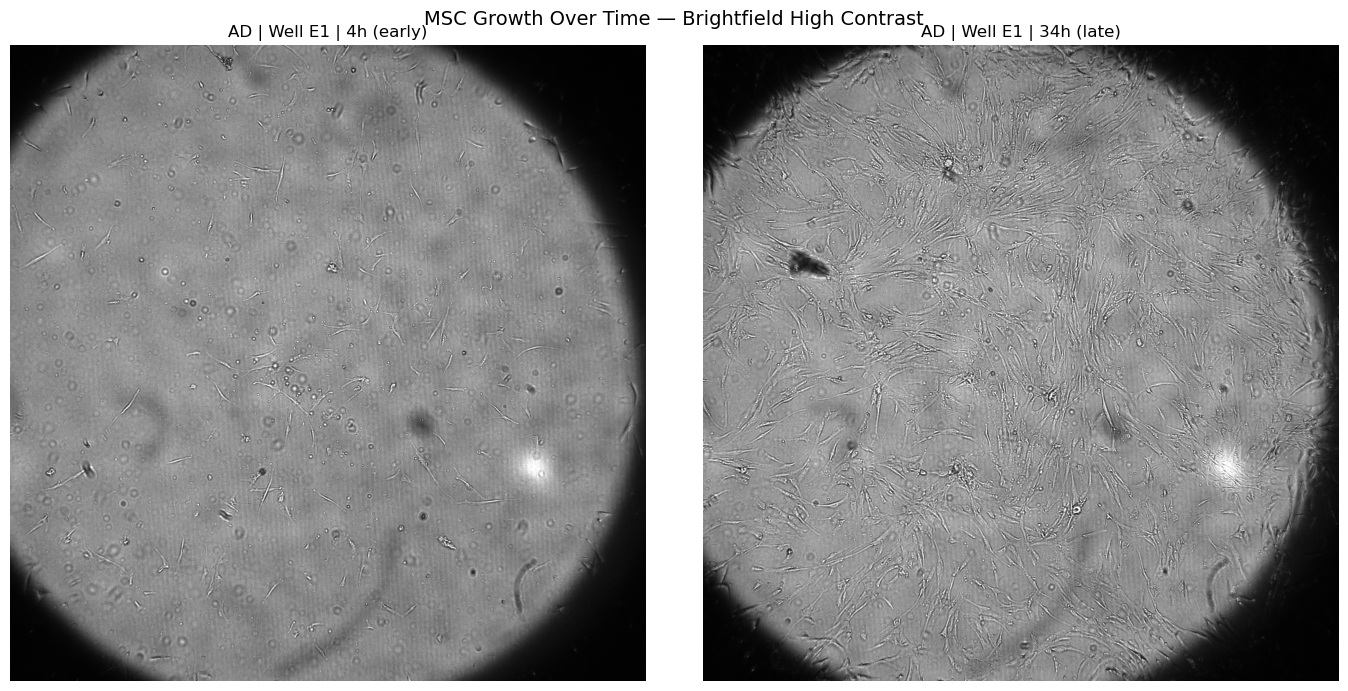

In [25]:
# Compare t04 and t34 to understand how cell density changes over time
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, filename, label in zip(
    axes,
    ["AD-E1-t04.tif", "AD-E1-t34.tif"],
    ["AD | Well E1 | 4h (early)", "AD | Well E1 | 34h (late)"]
):
    img = next(x["image"] for x in images if x["filename"] == filename)
    ax.imshow(img, cmap="gray")
    ax.set_title(label, fontsize=12)
    ax.axis("off")

plt.suptitle("MSC Growth Over Time — Brightfield High Contrast", fontsize=14)
plt.tight_layout()
plt.show()

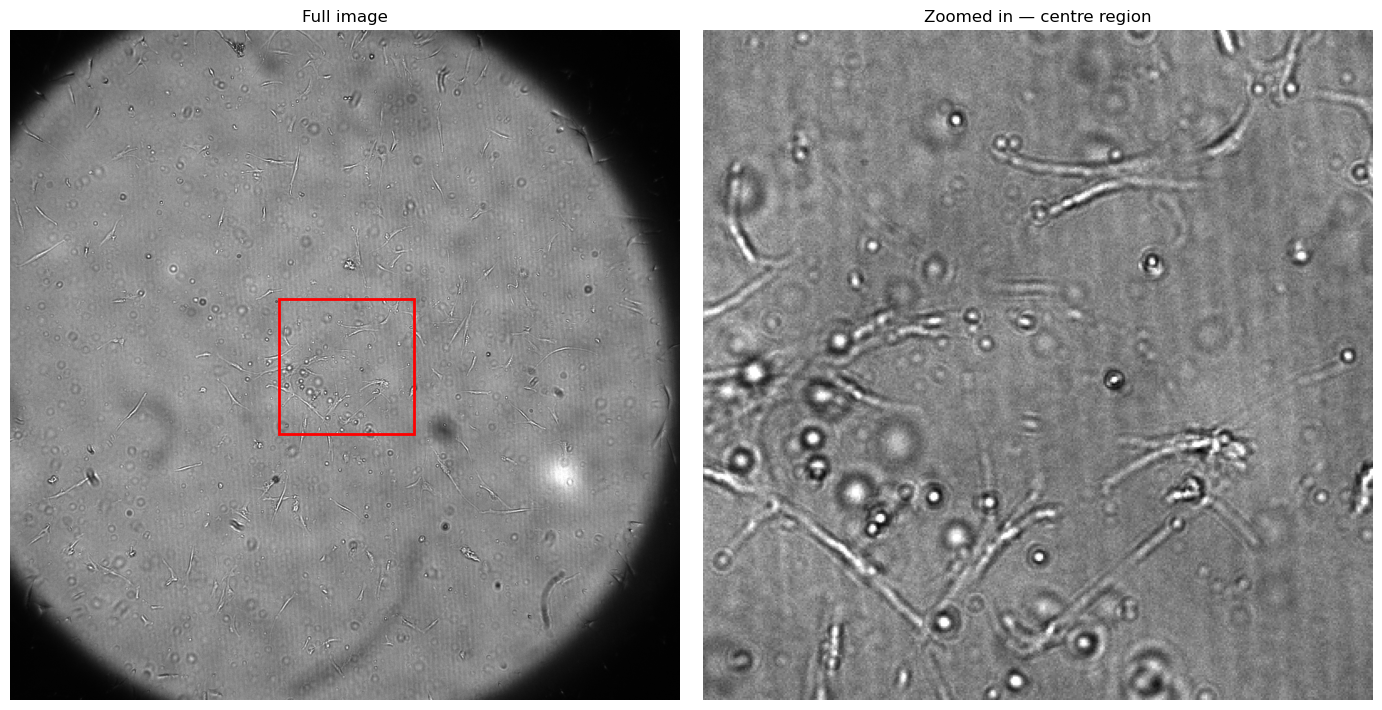

In [30]:
# Zoom into a small region to see individual cells clearly
img = next(x["image"] for x in images if x["filename"] == "AD-E1-t04.tif")

# Crop center region
crop = img[800:1200, 800:1200]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Full image")
axes[0].add_patch(plt.Rectangle((800, 800), 400, 400, fill=False, edgecolor='red', linewidth=2))
axes[0].axis("off")

axes[1].imshow(crop, cmap="gray")
axes[1].set_title("Zoomed in — centre region")
axes[1].axis("off")

plt.tight_layout()
plt.show()

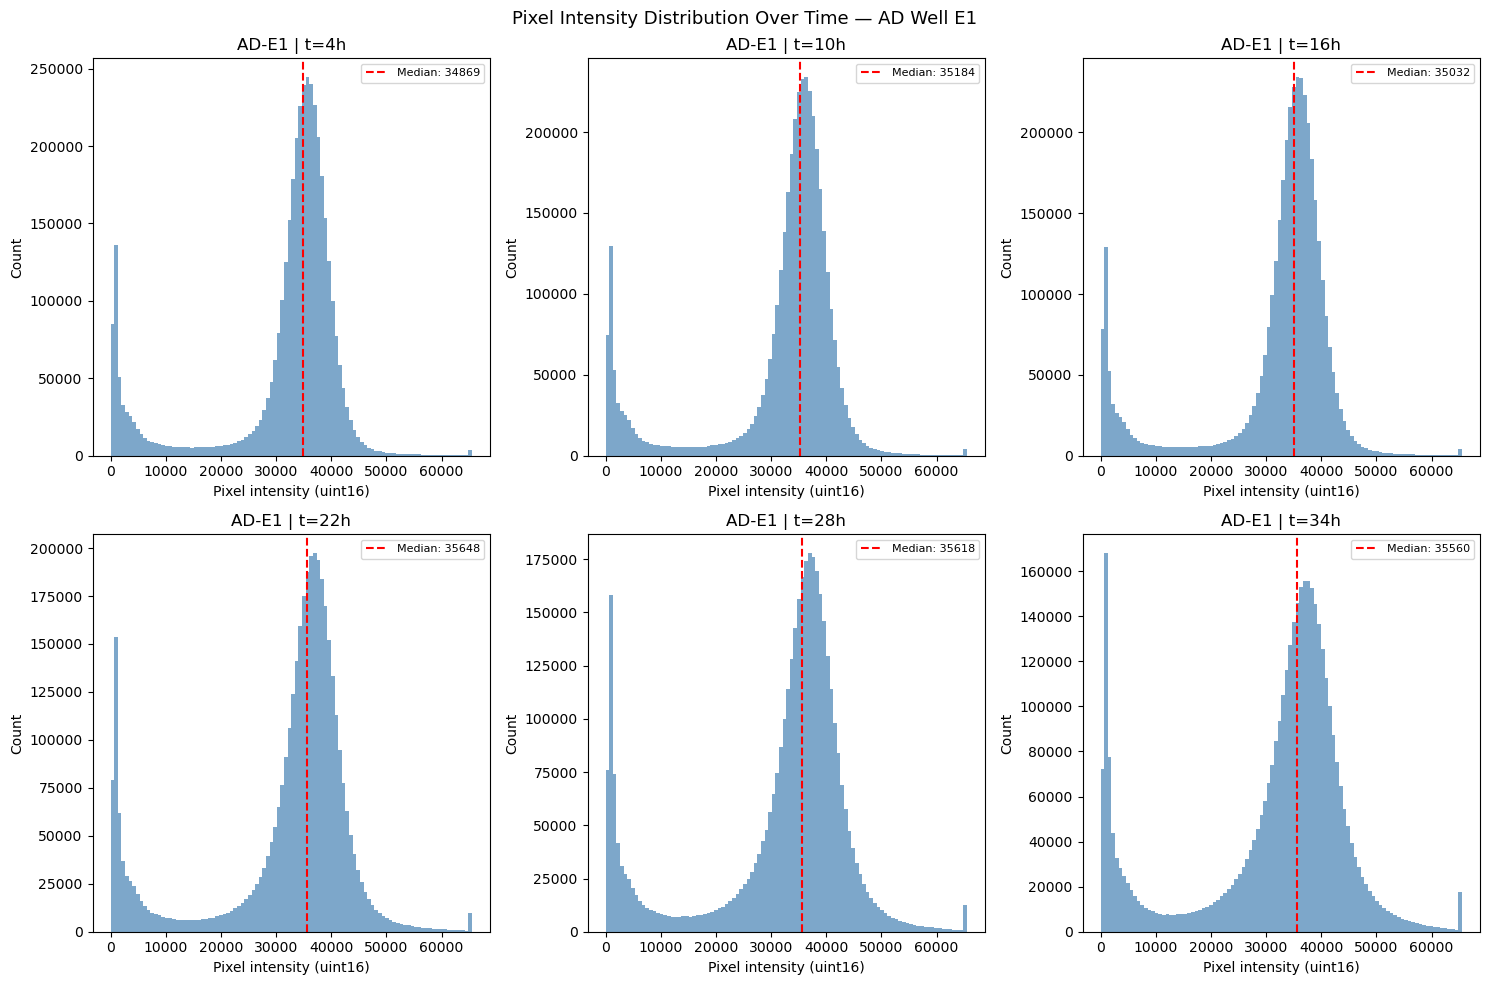

In [29]:
# Explore pixel intensity distribution — needed to inform preprocessing decisions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

timepoints = [4, 10, 16, 22, 28, 34]
ad_e1 = {x["timepoint"]: x for x in images if x["cell_line"] == "AD" and x["well"] == "E1"}

for ax, tp in zip(axes.flat, timepoints):
    img = ad_e1[tp]["image"]
    
    # Flatten and sample pixels for histogram
    pixels = img.flatten()
    ax.hist(pixels, bins=100, color='steelblue', alpha=0.7)
    ax.set_title(f"AD-E1 | t={tp}h")
    ax.set_xlabel("Pixel intensity (uint16)")
    ax.set_ylabel("Count")
    ax.axvline(np.median(pixels), color='red', linestyle='--', label=f'Median: {np.median(pixels):.0f}')
    ax.legend(fontsize=8)

plt.suptitle("Pixel Intensity Distribution Over Time — AD Well E1", fontsize=13)
plt.tight_layout()
plt.show()